In [1]:
# VGG16 모델을 불러오기
import keras

vggnet = keras.applications.VGG16()

2026-04-10 14:53:03.432723: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-10 14:53:03.456759: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-04-10 14:53:03.456786: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-04-10 14:53:03.457545: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-04-10 14:53:03.461570: I tensorflow/core/platform/cpu_feature_guar

In [4]:
!pip install pillow

In [5]:
from PIL import Image

dog_png = Image.open('images/dog.png')

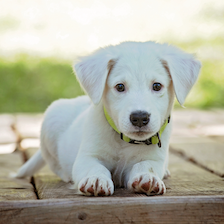

In [6]:
display(dog_png)

In [7]:
type(dog_png)

PIL.PngImagePlugin.PngImageFile

In [8]:
import numpy as np

dog_array = np.array(dog_png)
dog_array.shape

(224, 224, 3)

In [9]:
from keras.applications import vgg16

vgg_prep_dog = vgg16.preprocess_input( dog_array )

In [10]:
predictions = vggnet.predict(vgg_prep_dog[np.newaxis,:])

2026-04-10 15:12:19.499902: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8904
2026-04-10 15:12:19.652929: I external/local_tsl/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory


1/1 [==============================] - 1s 927ms/step


2026-04-10 15:12:20.259417: I external/local_tsl/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory


In [11]:
type(predictions)

numpy.ndarray

In [12]:
predictions.shape

(1, 1000)

In [13]:
predictions[0][:5]

array([4.8180169e-07, 6.3650799e-07, 1.0119359e-07, 6.5131999e-08,
       2.2665542e-07], dtype=float32)

In [15]:
max(predictions[0])

0.35704324

In [16]:
max_index = np.argmax( predictions[0] )
print( max_index , predictions[0][max_index] )

208 0.35704324


In [17]:
# 디코딩
import requests

url = "https://storage.googleapis.com/download.tensorflow.org/data/imagenet_class_index.json"
json_data = requests.get(url).json()

In [36]:
print(json_data)

{'0': ['n01440764', 'tench'], '1': ['n01443537', 'goldfish'], '2': ['n01484850', 'great_white_shark'], '3': ['n01491361', 'tiger_shark'], '4': ['n01494475', 'hammerhead'], '5': ['n01496331', 'electric_ray'], '6': ['n01498041', 'stingray'], '7': ['n01514668', 'cock'], '8': ['n01514859', 'hen'], '9': ['n01518878', 'ostrich'], '10': ['n01530575', 'brambling'], '11': ['n01531178', 'goldfinch'], '12': ['n01532829', 'house_finch'], '13': ['n01534433', 'junco'], '14': ['n01537544', 'indigo_bunting'], '15': ['n01558993', 'robin'], '16': ['n01560419', 'bulbul'], '17': ['n01580077', 'jay'], '18': ['n01582220', 'magpie'], '19': ['n01592084', 'chickadee'], '20': ['n01601694', 'water_ouzel'], '21': ['n01608432', 'kite'], '22': ['n01614925', 'bald_eagle'], '23': ['n01616318', 'vulture'], '24': ['n01622779', 'great_grey_owl'], '25': ['n01629819', 'European_fire_salamander'], '26': ['n01630670', 'common_newt'], '27': ['n01631663', 'eft'], '28': ['n01632458', 'spotted_salamander'], '29': ['n01632777', 

In [41]:
for n in range(1000):
    if 'cabbage' in json_data[str(n)][1] :
        print(json_data[str(n)][1])

cabbage_butterfly
head_cabbage


In [20]:
json_data[str(max_index)]

['n02099712', 'Labrador_retriever']

In [21]:
vgg16.decode_predictions( predictions )

[[('n02099712', 'Labrador_retriever', 0.35704324),
  ('n02099601', 'golden_retriever', 0.14472096),
  ('n02104029', 'kuvasz', 0.09278691),
  ('n02111500', 'Great_Pyrenees', 0.069202855),
  ('n02106166', 'Border_collie', 0.056665163)]]

In [22]:
vgg16.decode_predictions( predictions , top=3)

[[('n02099712', 'Labrador_retriever', 0.35704324),
  ('n02099601', 'golden_retriever', 0.14472096),
  ('n02104029', 'kuvasz', 0.09278691)]]

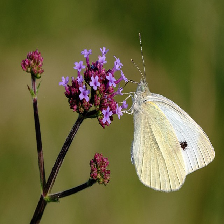

In [44]:
from tensorflow.keras.preprocessing import image
img = image.load_img('images/fly2.jpg', target_size=(224,224))
display(img)

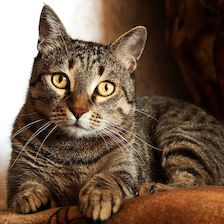

In [23]:
cat_png = Image.open('images/cat.png')
display(cat_png)

In [45]:
vgg_prep_cat = vgg16.preprocess_input(np.array(img))
predictions = vggnet.predict(vgg_prep_cat[np.newaxis, : ])
vgg16.decode_predictions(predictions)

1/1 [==============================] - 0s 11ms/step


[[('n02280649', 'cabbage_butterfly', 0.9100693),
  ('n02281406', 'sulphur_butterfly', 0.057819914),
  ('n02277742', 'ringlet', 0.025233023),
  ('n02281787', 'lycaenid', 0.0066856514),
  ('n02264363', 'lacewing', 9.7946344e-05)]]